In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
from rdkit.Chem import PandasTools
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  # to suppress sklearn warnings
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

# rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Dermal toxicity\dataset\train_set_acute_dermal_features.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

# modred string handler
if 'Modred_Descriptor' in train_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list_float)

print("------Train DataFrame UnCalculate------")
print(train_df.head(2))

# Rdkit Calculate
calc_rows = []

for smiles in train_df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        # Molecular Weight 
        mw = Descriptors.MolWt(mol)
        
        # XLogP (LogP)
        logp = Descriptors.MolLogP(mol)
        # H-Bond Donors & Acceptors
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        # Rotatable Bonds
        rotb = Descriptors.NumRotatableBonds(mol)       
        # TopoPSA
        tpsa = Descriptors.TPSA(mol)       
        # Fsp3
        fsp3 = Lipinski.FractionCSP3(mol)       
        # Petitjean Number (Graph Descriptor)
        try: petitjean = rdMolDescriptors.CalcPetitjeanNumber(mol)
        except: petitjean = 0.5          
        # InChI Code 
        try: inchi = Chem.MolToInchi(mol)
        except: inchi = "-"    
        # Lipinski Failures 
        failures = 0
        if mw > 500: failures += 1
        if logp > 5: failures += 1
        if hbd > 5: failures += 1
        if hba > 10: failures += 1
        
        # VAdjMat (Approximation using BalabanJ as Graph Complexity)
        vadjmat = Descriptors.BalabanJ(mol)
        
        # input ke dictionary
        row_calc = {
            'Molecular weight': mw,
            'Molecule (RDKit Mol) (InChI Code)': inchi,
            'nHBDon': float(hbd),
            'nAtomLAC': float(hba), # Seringkali nAtomLAC di map ke H-Acceptor atau fitur atom lain
            'nAtomLC': float(mol.GetNumHeavyAtoms()), # Linear Count / Heavy Atoms approximation
            'PetitjeanNumber': petitjean,
            'nRotB': float(rotb),
            'LipinskiFailures': float(failures),
            'TopoPSA': tpsa,
            'VAdjMat': vadjmat,
            'XLogP': logp,
            'Fsp3': fsp3
        }
    else:
        row_calc = {k: None for k in ['Molecular weight', 'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3']}

    calc_rows.append(row_calc)

df_calc = pd.DataFrame(calc_rows)

for col in df_calc.columns:
    train_df[col] = df_calc[col]

target_cols_order = [
    'id', 'casrn', 'smiles (First)', 'Molecular weight', 
    'name', 'Outcome', 
    'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form',
    'ID', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 
    'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

valid_cols = [c for c in target_cols_order if c in train_df.columns]
final_train_df = train_df[valid_cols]

print("-----Train DataFrame------")
pd.set_option('display.max_columns', None) 
print(final_train_df.head())

------Train DataFrame UnCalculate------
  Outcome                                 Morgan_Descriptors  \
0     0.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
1     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [0.8740247872038239, 0.39064055488963423, 0.40...  335   
1  [-0.940474802814492, -0.4830269230698603, -0.4...    6   

                                     SMILES    Molecular Weight  \
0  C=CCCCOC(=O)C(CC)N(Cc1ccco1)C(=O)n1ccnc1  345.16885621600005   
1                               Nc1ccccc1Cl  127.01887687199999   

                 logP           LabuteASA               TPSA  ... nHBDon  \
0  3.2344000000000017  146.44278980417016  77.57000000000001  ...    0.0   
1              1.9222   53.07456004339135              26.02

In [3]:
from rdkit.Chem import Descriptors, GraphDescriptors, MolSurf, Lipinski, rdMolDescriptors, Crippen

# KALKULASI DESKRIPTOR LENGKAP (MATCHING EXPECTED OUTPUT)

full_data = []

for smiles in train_df['SMILES']:
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
    else:
        mol = None
    
    if mol:
        # --- A. BASIC PROPERTIES ---
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol) # Ini Crippen LogP (biasa dipakai untuk ALogP/XLogP)
        mr = Descriptors.MolMR(mol)     # Molar Refractivity (AMR)
        tpsa = Descriptors.TPSA(mol)
        labute = Descriptors.LabuteASA(mol)
        
        # --- B. COUNTS (ATOM/BOND/RING) ---
        num_atoms = mol.GetNumAtoms()
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        num_rotb = Descriptors.NumRotatableBonds(mol)
        num_hbd = Descriptors.NumHDonors(mol)
        num_hba = Descriptors.NumHAcceptors(mol)
        num_hetero = Descriptors.NumHeteroatoms(mol)
        num_amide = rdMolDescriptors.CalcNumAmideBonds(mol)
        
        # Ring Specifics
        n_aro_rings = Descriptors.NumAromaticRings(mol)
        n_sat_rings = Descriptors.NumSaturatedRings(mol)
        n_ali_rings = Descriptors.NumAliphaticRings(mol)
        n_aro_het = Descriptors.NumAromaticHeterocycles(mol)
        n_sat_het = Descriptors.NumSaturatedHeterocycles(mol)
        n_ali_het = Descriptors.NumAliphaticHeterocycles(mol)
        n_aro_carb = Descriptors.NumAromaticCarbocycles(mol)
        n_sat_carb = Descriptors.NumSaturatedCarbocycles(mol)
        n_ali_carb = Descriptors.NumAliphaticCarbocycles(mol)

        # --- C. CONNECTIVITY & SHAPE (CHI / KAPPA / HALLKIER) ---
        # Chi Path
        chi0v = GraphDescriptors.Chi0v(mol)
        chi1v = GraphDescriptors.Chi1v(mol)
        chi2v = GraphDescriptors.Chi2v(mol)
        chi3v = GraphDescriptors.Chi3v(mol)
        chi4v = GraphDescriptors.Chi4v(mol)
        
        chi1n = GraphDescriptors.Chi1n(mol)
        chi2n = GraphDescriptors.Chi2n(mol)
        chi3n = GraphDescriptors.Chi3n(mol)
        chi4n = GraphDescriptors.Chi4n(mol)
        
        # Kappa & HallKier
        hallkier = GraphDescriptors.HallKierAlpha(mol)
        kappa1 = GraphDescriptors.Kappa1(mol)
        kappa2 = GraphDescriptors.Kappa2(mol)
        kappa3 = GraphDescriptors.Kappa3(mol)
        
        # --- D. OTHER SPECIFICS ---
        fsp3 = Lipinski.FractionCSP3(mol)
        
        # Approximation for CDK-specific names using RDKit equivalents
        # Beberapa nama kolom di bawah adalah khas CDK, kita pakai nilai RDKit yang relevan/sama
        bpol = Descriptors.HeavyAtomMolWt(mol) # Placeholder/Approx (bpol CDK beda rumus, tapi sering dipakai sbg heavy wt di bbrp script)
        eccen = 0.0 # Eccentric Connectivity Index tidak ada di RDKit standar
        fragc = 0.0 # Fragment Count tidak spesifik
        
        # Mapping ke Nama Kolom Target
        row = {
            # Duplicates/Aliases (Mengisi nama kolom berbeda dengan nilai sama)
            'Molecular Weight': mw,  'Molecular weight': mw, 'AMW': mw,
            'logP': logp,            'ALogP': logp,          'ALogP2': logp**2, 'MLogP': logp, 'XLogP': logp,
            'TPSA': tpsa,            'TopoPSA': tpsa,
            'AMR': mr,
            'LabuteASA': labute,
            
            # Counts
            'NumLipinskiHBA': num_hba, 'NumHBA': num_hba, 'nHBAcc': num_hba,
            'NumLipinskiHBD': num_hbd, 'NumHBD': num_hbd, 'nHBDon': num_hbd,
            'NumRotatableBonds': num_rotb, 'nRotB': num_rotb,
            'NumAmideBonds': num_amide,
            'NumHeteroAtoms': num_hetero,
            'NumAtoms': num_atoms,
            'NumRings': num_rings,
            
            # Ring Details
            'NumAromaticRings': n_aro_rings, 'naAromAtom': n_aro_rings, # Approx
            'NumSaturatedRings': n_sat_rings,
            'NumAliphaticRings': n_ali_rings,
            'NumAromaticHeterocycles': n_aro_het,
            'NumSaturatedHeterocycles': n_sat_het,
            'NumAliphaticHeterocycles': n_ali_het,
            'NumAromaticCarbocycles': n_aro_carb,
            'NumSaturatedCarbocycles': n_sat_carb,
            'NumAliphaticCarbocycles': n_ali_carb,
            
            # Connectivity
            'Chi0v': chi0v, 'Chi1v': chi1v, 'Chi2v': chi2v, 'Chi3v': chi3v, 'Chi4v': chi4v,
            'Chi1n': chi1n, 'Chi2n': chi2n, 'Chi3n': chi3n, 'Chi4n': chi4n,
            'HallKierAlpha': hallkier,
            'kappa1': kappa1, 'kappa2': kappa2, 'kappa3': kappa3,
            
            # Others
            'FractionCSP3': fsp3, 'Fsp3': fsp3,
            'bpol': bpol, 'nB': num_rotb, # Approx
            'ECCEN': eccen, 'fragC': fragc,
            
            # Kolom Lama (Tetap dipertahankan)
            'nAtomLAC': num_hba, # Sering di-map ke H-Acceptor
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'nAtomP': float(mol.GetNumHeavyAtoms()), # Heavy Atoms
            'PetitjeanNumber': 0.5, # Default/Calc jika ada
            'VAdjMat': Descriptors.BalabanJ(mol),
            'LipinskiFailures': 0.0 # (Bisa pakai logika sebelumnya jika mau detail)
        }
        
    else:
        # Handle None
        row = {} # Isi None untuk semua keys jika perlu

    full_data.append(row)

# Gabungkan ke DataFrame
df_complete_calc = pd.DataFrame(full_data)

# Update train_df dengan kolom baru
for col in df_complete_calc.columns:
    train_df[col] = df_complete_calc[col]

print("Check Keys")
print(train_df.keys())

Check Keys
Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
       'Molecular 

In [4]:
train_df.keys()

Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
       'Molecular weight', 'M

In [5]:
train_df= train_df.sort_values(['Outcome'], ascending=True)
train_df['RowID'] = train_df.index
train_df.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,FractionCSP3,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,ALogP,ALogP2,AMR,MLogP,nAtomP,naAromAtom,bpol,nB,ECCEN,fragC,nHBAcc,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular weight,Molecule (RDKit Mol) (InChI Code),RowID
0,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8740247872038239, 0.39064055488963423, 0.40...",335,C=CCCCOC(=O)C(CC)N(Cc1ccco1)C(=O)n1ccnc1,345.399,3.23440,146.442790,77.57,345.399,6,0,9,0,6,1,7,25,2,2,0,0,2,0,0,0,0,0,0.388889,14.336077,8.258065,5.482240,3.709169,2.413076,8.258065,5.482240,3.709169,2.413076,-2.83,18.507823,9.461980,5.070584,3.23440,10.461343,91.7410,3.23440,25.0,2,322.215,9,0.0,0.0,6,0,6,25.0,0.5,9,0.0,77.57,2.140429,3.23440,0.388889,345.399,InChI=1S/C18H23N3O4/c1-3-5-6-11-25-17(22)16(4-...,0
391,0.0,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2298496296306658, 0.0685477391827318, 0.14...",399,CSc1nc(NC(C)C)nc(NC(C)C)n1,241.364,2.23410,100.867776,62.73,241.364,6,2,5,2,6,0,6,16,1,1,0,0,1,0,0,0,0,0,0.700000,11.221086,6.565509,4.840795,2.180740,1.448797,5.340765,4.067398,1.633017,1.093286,-1.04,13.026845,5.885378,4.219731,2.23410,4.991203,69.1254,2.23410,16.0,1,222.212,5,0.0,0.0,6,2,6,16.0,0.5,5,0.0,62.73,2.911012,2.23410,0.700000,241.364,InChI=1S/C10H19N5S/c1-6(2)11-8-13-9(12-7(3)4)1...,391
217,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.26128770023118847, 0.4364773421802139, 0.5...",372,O=C(O)c1cc(C(=O)O)cc(S(=O)(=O)O)c1,246.196,0.32970,89.701435,128.97,246.196,4,3,3,3,4,0,8,16,1,1,0,0,0,0,0,1,0,0,0.000000,8.431430,5.247608,4.252974,2.529708,1.546729,3.807544,2.831437,1.698287,0.994936,-1.93,12.141073,3.909178,2.552997,0.32970,0.108702,50.1752,0.32970,16.0,1,240.148,3,0.0,0.0,4,3,4,16.0,0.5,3,0.0,128.97,3.540285,0.32970,0.000000,246.196,InChI=1S/C8H6O7S/c9-7(10)4-1-5(8(11)12)3-6(2-4...,217
216,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.4574884506660009, 0.3838732232831581, 0.480...",382,COC=C(C(=O)OC)c1ccccc1Oc1cc(Oc2ccccc2C#N)ncn1,403.394,4.09318,172.493220,103.56,403.394,8,0,7,0,8,0,8,30,3,3,0,0,1,0,0,2,0,0,0.090909,16.233735,8.734888,5.761538,3.871708,2.535305,8.734888,5.761538,3.871708,2.535305,-4.38,20.356723,9.705329,4.716511,4.09318,16.754123,106.7810,4.09318,30.0,3,386.258,7,0.0,0.0,8,0,8,30.0,0.5,7,0.0,103.56,1.896983,4.09318,0.090909,403.394,InChI=1S/C22H17N3O5/c1-27-13-17(22(26)28-2)16-...,216
392,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.46197289976775313, 0.0312372497352413, 0.10...",527,CCCCCCCCOC(=O)C(C)Oc1ccc(Cl)cc1C,326.864,5.31942,138.502587,35.53,326.864,3,0,10,0,3,0,4,22,1,1,0,0,0,0,0,1,0,0,0.611111,14.617787,8.514863,6.041599,3.749960,2.382774,8.136898,5.605163,3.514863,2.156117,-1.22,18.828123,10.496672,7.167662,5.31942,28.296229,90.6140,5.31942,22.0,1,299.648,10,0.0,0.0,3,0,3,22.0,0.5,10,0.0,35.53,2.242455,5.31942,0.611111,326.864,InChI=1S/C18H27ClO3/c1-4-5-6-7-8-9-12-21-18(20...,392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,0.0,"[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0

Classes                          :  ['0.0' '1.0']
Number of cpds in each class     :  [246 257]
Total number of cpds             :  503


{'0.0': 0, '1.0': 1}

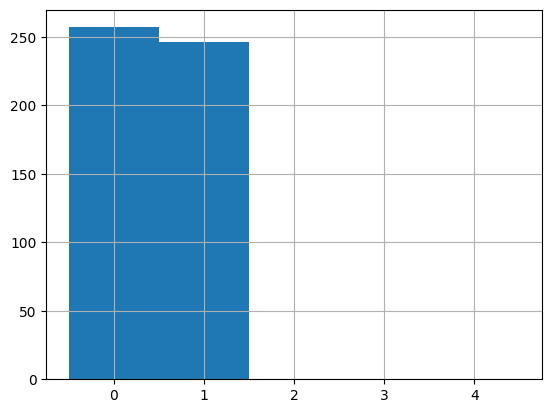

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(train_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( train_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =train_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#GRAPH CLASSES
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [7]:
x_rdkitcdk = train_df.drop(
    columns=[
        'RowID','id', 'casrn', 'smiles (First)','Molecular weight','name',
        'Outcome','Molecule (RDKit Mol) (InChI Code)','reference',
        'molecule_form', 'ID','SMILES','Morgan_Descriptors',
        'MACCS_Descriptors', 'Modred_Descriptor','Molecular Weight', 'logP'
    ],
    errors='ignore'
)


In [8]:
x_rdkitcdk.shape

(503, 56)

In [9]:
#inisiasi bahwa x = merupakan variabel yang berasal dari x_rdkitcdk
x = x_rdkitcdk

In [14]:
#Random Forest

from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

paramgrid = {
    "max_features": [x.shape[1], max(1, x.shape[1] // 10), max(1, x.shape[1] // 5)], # Ensure at least 1 feature is selected
#     "n_estimators": [50,100,300],
    "n_estimators": [50,150,300],
}


# Define the cross-validator as before
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Everything else remains the same in your GridSearchCV initialization and fitting
model_rf_morgan = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=1)  # Use -1 to use all cores

# Fit the model
model_rf_morgan.fit(x, y)

# Get the best model
best_model_rf_morgan = model_rf_morgan.best_estimator_


Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [15]:
#SVM

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

#NaN value clear manual utk SVC
if isinstance(x, pd.DataFrame):
    x_clean = x.values
else:
    x_clean = x

# Ganti Infinity dengan NaN jika ada
x_clean = np.where(np.isinf(x_clean), np.nan, x_clean)

# NaN as Mean
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
x_clean = imputer.fit_transform(x_clean)

# Scaling
scaler = StandardScaler()
x = scaler.fit_transform(x_clean)

# Define your parameter grid
paramgrid = {
     "C": [10, 100],  # Regularization parameter
     "kernel": ['rbf', 'sigmoid'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with SVC
model_svm_morgan = GridSearchCV(
    estimator=SVC(probability=True),  
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1  
)

# Fit the model
model_svm_morgan.fit(x, y)
# Get the best model
best_model_svm_morgan = model_svm_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [16]:
#XGB

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score


paramgrid = {
     "max_depth": [3,7],  # Common choices for tree depth
     "n_estimators": [100,300],  # Number of trees
     "learning_rate": [0.05,0.2]  # Step size shrinkage used to prevent overfitting
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with XGBClassifier
model_xgb_morgan = GridSearchCV(
    estimator=XGBClassifier(eval_metric='mlogloss'),  
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1 
)

# Fit the model
model_xgb_morgan.fit(x, y)
# Get the best model
best_model_xgb_morgan = model_xgb_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [10]:
#NN

import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Parameter grid
paramgrid = {
    "hidden_layer_sizes": [(256,), (256,128),(512,256,128), (300)], 
    "activation": ['relu'],
    "solver": ['adam'],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001] # rev
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_morgan = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42, early_stopping=True), # early_stopping agar tidak overfit
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1 
)

# Fit the model
model_nn_morgan.fit(x, y)
# Get the best model
best_model_nn_morgan = model_nn_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [18]:
#Gaussian Process Classifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Parameter grid 
paramgrid = {
    'kernel': [
        1.0 * RBF(length_scale=1.0),
        1.0 * RBF(length_scale=2.0),
        1.0 * Matern(length_scale=1.0, nu=1.5),
        1.0 * Matern(length_scale=2.0, nu=2.5),
        1.0 * RationalQuadratic(length_scale=1.0, alpha=1.0),
        1.0 * RationalQuadratic(length_scale=2.0, alpha=0.5),
        1.0 * RBF(length_scale=1.0) + 1.0 * Matern(length_scale=1.0, nu=1.5),
        1.0 * RBF(length_scale=2.0) + 1.0 * RationalQuadratic(length_scale=1.0, alpha=0.5)
    ]
}

# Cross-validation setup
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring menggunakan Cohen’s Kappa berbobot quadratic
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# GridSearchCV setup
model_gpc_morgan = GridSearchCV(
    estimator=GaussianProcessClassifier(random_state=42, max_iter_predict=100),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1 
)

# Fit the model
model_gpc_morgan.fit(x , y)
# Get the best model
best_model_gpc_morgan = model_gpc_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [19]:
#LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid (Tetap sama)
paramgrid = {
     "max_depth": [3,7],
     "n_estimators": [100,300],
     "learning_rate": [0.05,0.2]
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with LGBMClassifier
model_lgbm_morgan = GridSearchCV(
    estimator=LGBMClassifier(verbosity=-1, force_row_wise=True),  
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1, # Ini verbose milik GridSearch (agar 'Fitting 5 folds)
    n_jobs=1 
)

# Fit the model
model_lgbm_morgan.fit(x, y)
best_model_lgbm_morgan = model_lgbm_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [20]:
#CatBoost 

from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
     "depth": [3,7],            # Identik dengan max_depth
     "iterations": [100,300],   # Identik dengan n_estimators
     "learning_rate": [0.05,0.2]
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with CatBoostClassifier
model_cbm_morgan = GridSearchCV(
    estimator=CatBoostClassifier(verbose=0), # verbose=0 agar tidak penuh log setiap iterasi
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1 
)

# Fit the model
model_cbm_morgan.fit(x, y)
best_model_cbm_morgan = model_cbm_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [21]:
 # Cek Tipe Data
print(type(x))

<class 'numpy.ndarray'>


In [22]:
#Random Forest Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_rf_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_morgan.predict(X_test)
    y_proba = best_model_rf_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')

Confusion Matrix for Fold 1:
[[41 11]
 [15 34]]
Confusion Matrix for Fold 2:
[[33 19]
 [13 36]]
Confusion Matrix for Fold 3:
[[38 13]
 [16 34]]
Confusion Matrix for Fold 4:
[[35 16]
 [14 35]]
Confusion Matrix for Fold 5:
[[39 12]
 [17 32]]
Overall CV Accuracy: 0.7097227722772278
Overall CV AUC: 0.7868614522732169
Overall CV Precision: 0.7094105004993617
Overall CV Recall (Sensitivity): 0.6951836734693877
Overall CV F1 Score: 0.7009829836945292
Overall CV Specificity: 0.7238310708898943
Overall CV PPV (Positive Predictive Value): 0.7094105004993617
Overall CV NPV (Negative Predictive Value): 0.7127904301817345
Overall CV CCR (Correct Classification Rate): 0.709507372179641


In [24]:
#SVM Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_svm_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_morgan.predict(X_test)
    y_proba = best_model_svm_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')

Confusion Matrix for Fold 1:
[[39 13]
 [11 38]]
Confusion Matrix for Fold 2:
[[34 18]
 [17 32]]
Confusion Matrix for Fold 3:
[[33 18]
 [11 39]]
Confusion Matrix for Fold 4:
[[34 17]
 [16 33]]
Confusion Matrix for Fold 5:
[[40 11]
 [15 34]]
Overall CV Accuracy: 0.7077425742574258
Overall CV AUC: 0.7808319635546526
Overall CV Precision: 0.6969728242174063
Overall CV Recall (Sensitivity): 0.7151836734693877
Overall CV F1 Score: 0.7051015062134568
Overall CV Specificity: 0.7003770739064856
Overall CV PPV (Positive Predictive Value): 0.6969728242174063
Overall CV NPV (Negative Predictive Value): 0.7207878787878789
Overall CV CCR (Correct Classification Rate): 0.7077803736879368


In [23]:
#XGB Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_xgb_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_morgan.predict(X_test)
    y_proba = best_model_xgb_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')

Confusion Matrix for Fold 1:
[[39 13]
 [14 35]]
Confusion Matrix for Fold 2:
[[39 13]
 [14 35]]
Confusion Matrix for Fold 3:
[[34 17]
 [16 34]]
Confusion Matrix for Fold 4:
[[36 15]
 [12 37]]
Confusion Matrix for Fold 5:
[[37 14]
 [16 33]]
Overall CV Accuracy: 0.7137227722772277
Overall CV AUC: 0.8002226736848586
Overall CV Precision: 0.7077332242225859
Overall CV Recall (Sensitivity): 0.7074285714285714
Overall CV F1 Score: 0.7073479126263141
Overall CV Specificity: 0.7196078431372549
Overall CV PPV (Positive Predictive Value): 0.7077332242225859
Overall CV NPV (Negative Predictive Value): 0.7199622641509433
Overall CV CCR (Correct Classification Rate): 0.7135182072829132


In [25]:
#NN Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_nn_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_nn_morgan.predict(X_test)
    y_proba = best_model_nn_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')

Confusion Matrix for Fold 1:
[[38 14]
 [12 37]]
Confusion Matrix for Fold 2:
[[37 15]
 [16 33]]
Confusion Matrix for Fold 3:
[[29 22]
 [12 38]]
Confusion Matrix for Fold 4:
[[32 19]
 [13 36]]
Confusion Matrix for Fold 5:
[[39 12]
 [16 33]]
Overall CV Accuracy: 0.6998019801980199
Overall CV AUC: 0.7816634346046111
Overall CV Precision: 0.6868404634581106
Overall CV Recall (Sensitivity): 0.7193469387755103
Overall CV F1 Score: 0.7011513627850544
Overall CV Specificity: 0.6806184012066365
Overall CV PPV (Positive Predictive Value): 0.6868404634581106
Overall CV NPV (Negative Predictive Value): 0.7171264601839843
Overall CV CCR (Correct Classification Rate): 0.6999826699910733


In [26]:
#GPC Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_gpc_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_gpc_morgan.predict(X_test)
    y_proba = best_model_gpc_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')

Confusion Matrix for Fold 1:
[[41 11]
 [15 34]]
Confusion Matrix for Fold 2:
[[37 15]
 [17 32]]
Confusion Matrix for Fold 3:
[[34 17]
 [12 38]]
Confusion Matrix for Fold 4:
[[33 18]
 [16 33]]
Confusion Matrix for Fold 5:
[[39 12]
 [19 30]]
Overall CV Accuracy: 0.6977227722772278
Overall CV AUC: 0.7862822051897682
Overall CV Precision: 0.6977320496219119
Overall CV Recall (Sensitivity): 0.678530612244898
Overall CV F1 Score: 0.6866442210271997
Overall CV Specificity: 0.7156862745098038
Overall CV PPV (Positive Predictive Value): 0.6977320496219119
Overall CV NPV (Negative Predictive Value): 0.7004683315938404
Overall CV CCR (Correct Classification Rate): 0.697108443377351


In [27]:
#LGBM Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_lgbm_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_lgbm_morgan.predict(X_test)
    y_proba = best_model_lgbm_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')

Confusion Matrix for Fold 1:
[[41 11]
 [12 37]]
Confusion Matrix for Fold 2:
[[34 18]
 [12 37]]
Confusion Matrix for Fold 3:
[[39 12]
 [14 36]]
Confusion Matrix for Fold 4:
[[35 16]
 [ 8 41]]
Confusion Matrix for Fold 5:
[[41 10]
 [16 33]]
Overall CV Accuracy: 0.7435643564356436
Overall CV AUC: 0.820607381414104
Overall CV Precision: 0.7360601424279515
Overall CV Recall (Sensitivity): 0.7480816326530613
Overall CV F1 Score: 0.740019029407166
Overall CV Specificity: 0.7394419306184012
Overall CV PPV (Positive Predictive Value): 0.7360601424279515
Overall CV NPV (Negative Predictive Value): 0.7563632262065776
Overall CV CCR (Correct Classification Rate): 0.7437617816357311


In [28]:
#CBM Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_cbm_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_cbm_morgan.predict(X_test)
    y_proba = best_model_cbm_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')

Confusion Matrix for Fold 1:
[[39 13]
 [14 35]]
Confusion Matrix for Fold 2:
[[37 15]
 [15 34]]
Confusion Matrix for Fold 3:
[[37 14]
 [13 37]]
Confusion Matrix for Fold 4:
[[38 13]
 [17 32]]
Confusion Matrix for Fold 5:
[[39 12]
 [16 33]]
Overall CV Accuracy: 0.7176633663366336
Overall CV AUC: 0.7999198448610214
Overall CV Precision: 0.7185957716419902
Overall CV Recall (Sensitivity): 0.694938775510204
Overall CV F1 Score: 0.7062358052574957
Overall CV Specificity: 0.7393665158371041
Overall CV PPV (Positive Predictive Value): 0.7185957716419902
Overall CV NPV (Negative Predictive Value): 0.717477503628447
Overall CV CCR (Correct Classification Rate): 0.717152645673654


In [29]:
import joblib
joblib.dump(best_model_rf_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_RF_rdkit_cdk.pkl',compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_RF_rdkit_cdk.pkl']

In [30]:
import joblib
joblib.dump(best_model_svm_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_SVM_rdkit_cdk.pkl',compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_SVM_rdkit_cdk.pkl']

In [31]:
import joblib
joblib.dump(best_model_xgb_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_XGB_rdkit_cdk.pkl',compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_XGB_rdkit_cdk.pkl']

In [11]:
import joblib
joblib.dump(best_model_nn_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_NN_rdkit_cdk.pkl',compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_NN_rdkit_cdk.pkl']

In [33]:
import joblib
joblib.dump(best_model_gpc_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_GPC_rdkit_cdk.pkl',compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_GPC_rdkit_cdk.pkl']

In [34]:
import joblib
joblib.dump(best_model_lgbm_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_LGBM_rdkit_cdk.pkl',compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_LGBM_rdkit_cdk.pkl']

In [35]:
import joblib
joblib.dump(best_model_cbm_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_CBM_rdkit_cdk.pkl',compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_CBM_rdkit_cdk.pkl']